In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

#### Retriever

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = []

for sublist in docs:
    for item in sublist:
        docs_list.append(item)
docs_list

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
doc_splits = splitter.split_documents(docs_list)

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectordb = FAISS.from_documents(
    documents = doc_splits,
    embedding = embeddings
)


retriever = vectordb.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### Query Analysis

In [30]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

class RouteDecision(BaseModel):
    """Routing decision for query analysis"""
    
    route_decision: str = Field(description="Must be exactly 'retrieve' or 'generate'")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
router_llm = llm.with_structured_output(RouteDecision)

In [31]:
system = """Decide whether the query requires document retrieval.

- Return "retrieve" → if external or factual knowledge is needed
- Return "generate" → if it can be answered directly (small talk, generic response)

Return only one word: retrieve or generate"""

router_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

In [47]:
router = router_prompt | router_llm
#question = "what is the refund process in your company"
question = "how are you?"
ans = router.invoke({"question": question})
print(ans.route_decision)

generate


#### Grader

In [48]:
class GradeDocuments(BaseModel):
    """Binary Score for relevance check on retrieved documents."""
    
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")


llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
grader_llm = llm.with_structured_output(GradeDocuments)

In [6]:
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

In [7]:
retrieval_grader = grade_prompt | grader_llm

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


#### Generator

In [14]:
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template("""
Use the following context to answer the question.
If the answer is not in the context, say you don't know.

Question: {question}

Context:
{context}

Answer:
""")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

In LLM‑powered autonomous agents “memory” is split into two complementary parts:

| Type of memory | What it is | How it works |
|----------------|------------|--------------|
| **Short‑term memory** | The information the model can keep “in‑context” during a single prompt. | It is just the text that is fed to the LLM as part of the prompt (in‑context learning). The agent can refer to recent observations, plans, or tool results that are included in the current prompt window. |
| **Long‑term memory** | An external, persistent store that lets the agent retain an essentially unlimited amount of experience. | Typically implemented with a vector store (or other database) that records observations, events, or natural‑language summaries of what the agent has done. When the agent needs to recall something, a retrieval model (e.g., Maximum Inner Product Search) fetches the most relevant entries based on relevance, recency, and importance, and injects them back into the prompt as context. Some de

In [54]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
direct_llm = llm | StrOutputParser()

#### Rewrite Query

In [9]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human","Here is the initial question: \n\n {question} \n Formulate an improved question.",),
    ]
)

query_rewriter = rewrite_prompt | llm | StrOutputParser()
query_rewriter.invoke({"question": question})

'**Improved search‑optimized question:**  \n*How does memory work in autonomous AI agents, and what techniques are used to store, retrieve, and manage information for their decision‑making processes?*'

#### Search

In [10]:
from langchain_tavily import TavilySearch

tavily_web_search = TavilySearch(k=3)

#### State of Graph

In [13]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        route: routing decision
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    route: str
    generation: str
    web_search: str
    documents: List[str]

#### Nodes

In [55]:
from langchain_core.documents import Document

def query_analysis(state):
    """
    Decide whether retrieval is needed or not
    """

    print("---QUERY ANALYSIS---")

    question = state["question"]

    ans = router.invoke({"question": question})
    decision = ans.route_decision                

    print(f"---DECISION: {decision}---")

    return {"question": question, "route": decision}

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}
    

def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    
    for d in documents:
        score = retrieval_grader.invoke({"question": question, "document": d.page_content})
        grade = score.binary_score
        
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
            
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def generate(state):
    """Generate answer (RAG or Direct)"""

    if state["route"] == "generate":
        print("---GENERATE---")
        question = state["question"]
        generation = direct_llm.invoke(question)
        return {"question": question,"generation": generation}
    
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]

    better_question = query_rewriter.invoke({"question": question})
    return {"question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = tavily_web_search.invoke({"query": question})
    web_results = "\n\n".join([d["content"] for d in docs['results']])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

def route_after_analysis(state):
    """
    Route to retrieve or generate
    """

    print("---ROUTING AFTER ANALYSIS---")

    if state["route"] == "retrieve":
        print("---RETRIEVE THE DOCUMENTS---")
        return "retrieve"
    else:
        print("---GENERATE THE ANSWER---")
        return "generate"

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")

    web_search = state["web_search"]

    if web_search == "Yes":
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"

In [56]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

workflow.add_node("query_analysis", query_analysis) # query_analysis
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

workflow.add_edge(START, "query_analysis")
workflow.add_conditional_edges(
    "query_analysis",
    route_after_analysis,
    {
        "retrieve": "retrieve",
        "generate": "generate",
    },
)

workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

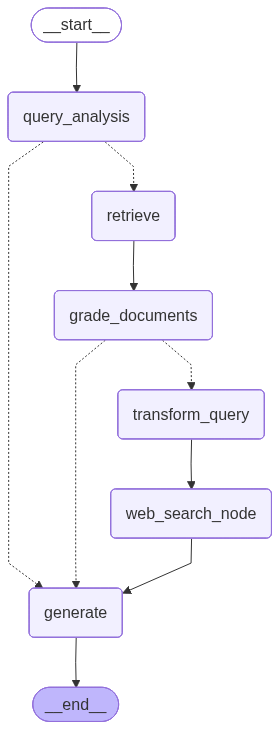

In [52]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [57]:
app.invoke({"question":"How are you?"})

---QUERY ANALYSIS---
---DECISION: generate---
---ROUTING AFTER ANALYSIS---
---GENERATE THE ANSWER---
---GENERATE---


{'question': 'How are you?',
 'route': 'generate',
 'generation': "I'm doing great, thanks for asking! How can I help you today?"}

In [58]:
app.invoke({"question":"agent memory"})

---QUERY ANALYSIS---
---DECISION: generate---
---ROUTING AFTER ANALYSIS---
---GENERATE THE ANSWER---
---GENERATE---


{'question': 'agent memory',
 'route': 'generate',
 'generation': '## Agent Memory – A Quick‑Start Guide\n\nBelow is a compact yet thorough overview of **agent memory**—what it is, why it matters, the main design patterns, and practical tips for building or using it with modern LLM‑powered agents.\n\n---\n\n### 1️⃣ What “Agent Memory” Means\n\n| Term | Rough Analogy | Typical Use in LLM Agents |\n|------|---------------|---------------------------|\n| **Short‑term (working) memory** | Your mental “scratchpad” while solving a problem | Stores the most recent user turns, tool calls, and intermediate reasoning steps. Usually kept in the prompt context (e.g., the last\u202fN\u202fmessages). |\n| **Long‑term (persistent) memory** | Your personal diary or knowledge base | Persists across sessions. Can be a vector store, relational DB, key‑value cache, or even a file system. Used for facts the agent should remember forever (user preferences, past purchases, project history, etc.). |\n| **Epis

In [59]:
app.invoke({'question':'What are the types of agent memory?'})

---QUERY ANALYSIS---
---DECISION: retrieve---
---ROUTING AFTER ANALYSIS---
---RETRIEVE THE DOCUMENTS---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': '**Improved question:**  \nWhat are the different categories or types of memory used in artificial/intelligent agents?',
 'route': 'retrieve',
 'generation': '**Memory in artificial / intelligent agents is usually broken down into several complementary categories.  \nThe most common ones that appear in the literature (and in the supplied documents) are:**\n\n| Category | What it stores / how it works | Typical implementation |\n|----------|------------------------------|------------------------|\n| **Sensory (or perception) memory** | Low‑level embeddings of raw inputs (text, images, audio, etc.) that the agent can later attend to. | Learned encoder models that turn raw data into vector representations. |\n| **Short‑term (or working) memory** | The information that is currently “in the head” of the model – the prompt, recent observations, and the chain‑of‑thought that the LLM is processing. It is limited by the model’s context window. | In‑context learning (the prompt + re